# Week 2: Advanced Feature Engineering for Time-Series Forecasting

This notebook focuses on transforming raw time-series data into a **model-ready dataset** using advanced feature engineering techniques.

---

## Objectives

- Extract meaningful **date-based features**
- Create **lag features** to capture historical patterns
- Generate **rolling statistics** for trend smoothing
- Apply **cyclical encoding** for seasonality
- Introduce **trend feature** for time progression
- Prevent **data leakage** in feature construction
- Perform **time-series aware train-test split**
- Prepare dataset for robust model training

##  Data Loading

Load the processed dataset generated from Week 1.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/daily_demand.csv')
df.head()

,date,quantity
0,2024-04-01,475
1,2024-04-02,456
2,2024-04-03,466
3,2024-04-04,415
4,2024-04-05,446


In [2]:
df['date'] = pd.to_datetime(df['date'])

In [3]:
df = df.sort_values('date').reset_index(drop=True)

## Date Feature Engineering

Convert the date column into datetime format and extract useful features such as day, month, year, and weekday information.

In [4]:
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

df['day_of_week'] = df['date'].dt.dayofweek   # 0 = Monday, 6 = Sunday
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

In [5]:
df.head()

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend
0,2024-04-01,475,1,4,2024,0,14,0
1,2024-04-02,456,2,4,2024,1,14,0
2,2024-04-03,466,3,4,2024,2,14,0
3,2024-04-04,415,4,4,2024,3,14,0
4,2024-04-05,446,5,4,2024,4,14,0


## Cyclical Encoding

Time-based features such as days and months are cyclical in nature.

We transform them using sine and cosine functions to preserve their cyclical relationships:
- Day of week (weekly pattern)
- Month (yearly seasonality)

This helps models better understand periodic behavior.

In [6]:
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [7]:
df.head(10)

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,month_sin,month_cos
0,2024-04-01,475,1,4,2024,0,14,0,0.000000,1.000000,0.866025,-0.5
1,2024-04-02,456,2,4,2024,1,14,0,0.781831,0.623490,0.866025,-0.5
2,2024-04-03,466,3,4,2024,2,14,0,0.974928,-0.222521,0.866025,-0.5
3,2024-04-04,415,4,4,2024,3,14,0,0.433884,-0.900969,0.866025,-0.5
4,2024-04-05,446,5,4,2024,4,14,0,-0.433884,-0.900969,0.866025,-0.5
5,2024-04-06,428,6,4,2024,5,14,1,-0.974928,-0.222521,0.866025,-0.5
6,2024-04-07,417,7,4,2024,6,14,1,-0.781831,0.623490,0.866025,-0.5
7,2024-04-08,444,8,4,2024,0,15,0,0.000000,1.000000,0.866025,-0.5
8,2024-04-09,426,9,4,2024,1,15,0,0.781831,0.623490,0.866025,-0.5
9,2024-04-10,474,10,4,2024,2,15,0,0.974928,-0.222521,0.866025,-0.5


## Trend Feature

A trend feature is added to represent the progression of time.

This allows models to capture long-term upward or downward patterns in demand.

In [8]:
df['trend'] = np.arange(len(df))

In [9]:
df.head(1)

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,month_sin,month_cos,trend
0,2024-04-01,475,1,4,2024,0,14,0,0.0,1.0,0.866025,-0.5,0


## Lag Features

Lag features allow the model to learn from past observations.

We create multiple lag features to capture:
- Short-term patterns (lag_1, lag_3)
- Weekly seasonality (lag_7)
- Medium-term trends (lag_14, lag_21)

These features are essential for time-series forecasting models.

In [10]:
lags = [1, 3, 7, 14, 21]

for lag in lags:
    df[f'lag_{lag}'] = df['quantity'].shift(lag)

In [11]:
df.head(10)

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,month_sin,month_cos,trend,lag_1,lag_3,lag_7,lag_14,lag_21
0,2024-04-01,475,1,4,2024,0,14,0,0.000000,1.000000,0.866025,-0.5,0,NaN,NaN,NaN,NaN,NaN
1,2024-04-02,456,2,4,2024,1,14,0,0.781831,0.623490,0.866025,-0.5,1,475.0,NaN,NaN,NaN,NaN
2,2024-04-03,466,3,4,2024,2,14,0,0.974928,-0.222521,0.866025,-0.5,2,456.0,NaN,NaN,NaN,NaN
3,2024-04-04,415,4,4,2024,3,14,0,0.433884,-0.900969,0.866025,-0.5,3,466.0,475.0,NaN,NaN,NaN
4,2024-04-05,446,5,4,2024,4,14,0,-0.433884,-0.900969,0.866025,-0.5,4,415.0,456.0,NaN,NaN,NaN
5,2024-04-06,428,6,4,2024,5,14,1,-0.974928,-0.222521,0.866025,-0.5,5,446.0,466.0,NaN,NaN,NaN
6,2024-04-07,417,7,4,2024,6,14,1,-0.781831,0.623490,0.866025,-0.5,6,428.0,415.0,NaN,NaN,NaN
7,2024-04-08,444,8,4,2024,0,15,0,0.000000,1.000000,0.866025,-0.5,7,417.0,446.0,475.0,NaN,NaN
8,2024-04-09,426,9,4,2024,1,15,0,0.781831,0.623490,0.866025,-0.5,8,444.0,428.0,456.0,NaN,NaN
9,2024-04-10,474,10,4,2024,2,15,0,0.974928,-0.222521,0.866025,-0.5,9,426.0,417.0,466.0,NaN,NaN


## Rolling Features (Leakage-Free)

Rolling statistics help capture trends and smooth fluctuations.

To avoid **data leakage**, we shift the target variable before applying rolling calculations.

Generated features:
- Rolling Mean (trend)
- Rolling Standard Deviation (volatility)
- Rolling Min/Max (range)

In [12]:
windows = [3, 7, 14]

for window in windows:
    df[f'rolling_mean_{window}'] = df['quantity'].shift(1).rolling(window).mean()
    df[f'rolling_std_{window}'] = df['quantity'].shift(1).rolling(window).std()
    df[f'rolling_min_{window}'] = df['quantity'].shift(1).rolling(window).min()
    df[f'rolling_max_{window}'] = df['quantity'].shift(1).rolling(window).max()

In [13]:
df.head(10)

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,...,rolling_min_3,rolling_max_3,rolling_mean_7,rolling_std_7,rolling_min_7,rolling_max_7,rolling_mean_14,rolling_std_14,rolling_min_14,rolling_max_14
0,2024-04-01,475,1,4,2024,0,14,0,0.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-04-02,456,2,4,2024,1,14,0,0.781831,0.623490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-04-03,466,3,4,2024,2,14,0,0.974928,-0.222521,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-04-04,415,4,4,2024,3,14,0,0.433884,-0.900969,...,456.0,475.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-04-05,446,5,4,2024,4,14,0,-0.433884,-0.900969,...,415.0,466.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-04-06,428,6,4,2024,5,14,1,-0.974928,-0.222521,...,415.0,466.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-04-07,417,7,4,2024,6,14,1,-0.781831,0.623490,...,415.0,446.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2024-04-08,444,8,4,2024,0,15,0,0.000000,1.000000,...,417.0,446.0,443.285714,23.858711,415.0,475.0,NaN,NaN,NaN,NaN
8,2024-04-09,426,9,4,2024,1,15,0,0.781831,0.623490,...,417.0,444.0,438.857143,19.463030,415.0,466.0,NaN,NaN,NaN,NaN
9,2024-04-10,474,10,4,2024,2,15,0,0.974928,-0.222521,...,417.0,444.0,434.571429,18.329004,415.0,466.0,NaN,NaN,NaN,NaN


## Handling Missing Values

Lag and rolling features introduce missing values at the beginning of the dataset.

These rows are safely removed since they do not contain sufficient historical context.

In [14]:
df = df.dropna().reset_index(drop=True)

In [15]:
df.head()
df.isnull().sum()

date               0
quantity           0
day                0
month              0
year               0
day_of_week        0
week_of_year       0
is_weekend         0
day_of_week_sin    0
day_of_week_cos    0
month_sin          0
month_cos          0
trend              0
lag_1              0
lag_3              0
lag_7              0
lag_14             0
lag_21             0
rolling_mean_3     0
rolling_std_3      0
rolling_min_3      0
rolling_max_3      0
rolling_mean_7     0
rolling_std_7      0
rolling_min_7      0
rolling_max_7      0
rolling_mean_14    0
rolling_std_14     0
rolling_min_14     0
rolling_max_14     0
dtype: int64

## Prepare dataset for modeling

In [16]:
# dataset for modeling

df_model = df.copy()

# target
target = 'quantity'

# Feature columns
features = [col for col in df_model.columns if col not in ['date', target, 'year']]

print("Total Features:", len(features))
print(features)

Total Features: 27
['day', 'month', 'day_of_week', 'week_of_year', 'is_weekend', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'trend', 'lag_1', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'rolling_mean_3', 'rolling_std_3', 'rolling_min_3', 'rolling_max_3', 'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_min_14', 'rolling_max_14']


## Time-Series Train-Test Split

Unlike random splitting, time-series data must be split chronologically.

- Training set → Past data
- Testing set → Future data

This ensures realistic model evaluation and avoids data leakage.

In [17]:
# Time-Series Train-Test Split

train_size = int(len(df_model) * 0.8)

train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (275, 30)
Test shape: (69, 30)


## Define X (Features) and y (Target) for Train/Test Sets

In [18]:
# Separate features and target

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (275, 27)
X_test: (69, 27)


## Feature Correlation Check

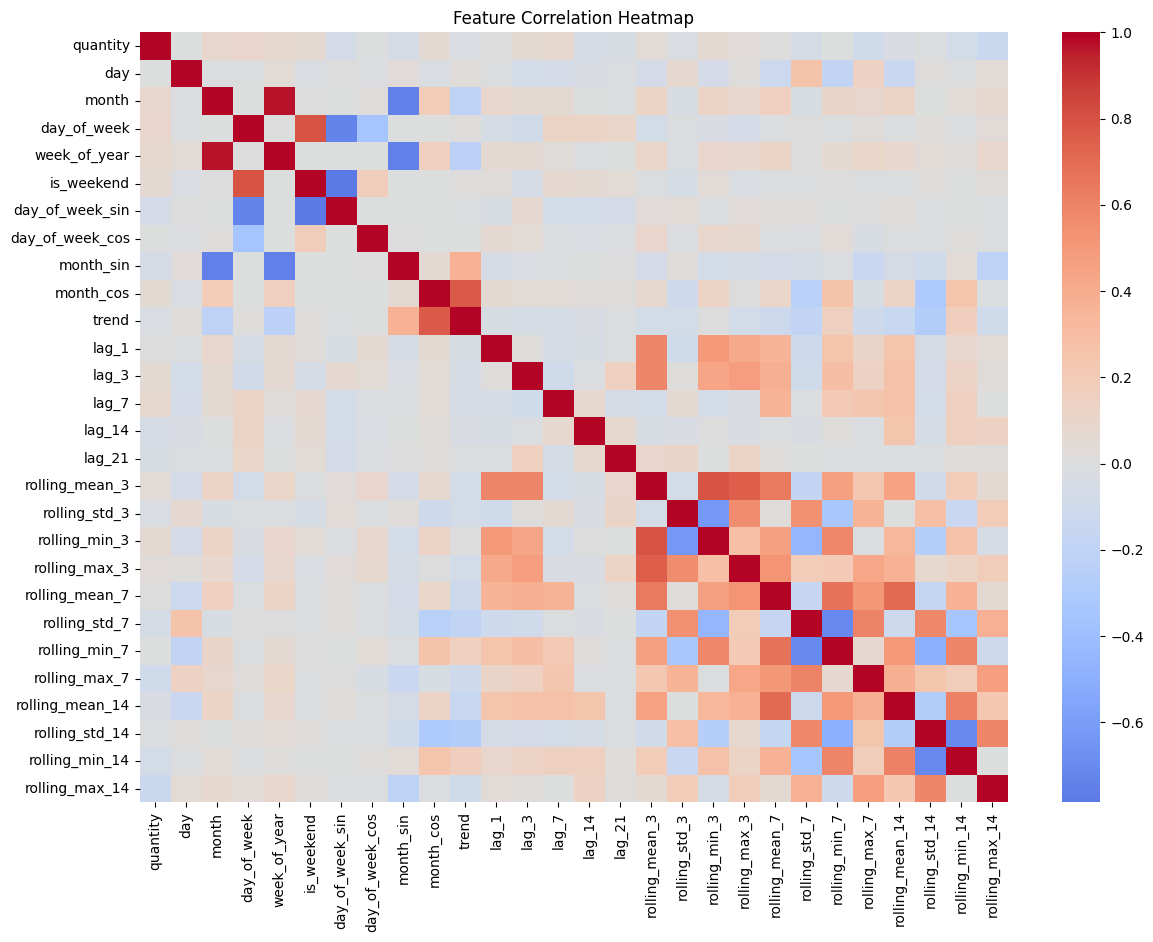

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

corr = df.drop(columns=['date', 'year']).corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

## Save processed datasets

In [20]:
# Saving processed datasets

df_model.to_csv('../data/processed/model_ready_data.csv', index=False)

train.to_csv('../data/processed/train.csv', index=False)
test.to_csv('../data/processed/test.csv', index=False)

print("Files saved successfully!")

Files saved successfully!


## FEATURE IMPORTANCE PREVIEW

In [21]:
# feature importance using correlation with target

corr_with_target = df_model.corr()['quantity'].sort_values(ascending=False)

print(corr_with_target)

quantity           1.000000
day_of_week        0.096113
month              0.092810
lag_7              0.076202
week_of_year       0.074248
rolling_min_3      0.056212
is_weekend         0.054172
month_cos          0.050612
lag_3              0.047898
rolling_mean_3     0.036901
rolling_max_3      0.026815
lag_1              0.008175
rolling_mean_7     0.003735
rolling_min_7     -0.001454
day               -0.002065
day_of_week_cos   -0.003269
rolling_std_14    -0.015993
rolling_std_3     -0.026435
trend             -0.029621
date              -0.029621
rolling_mean_14   -0.038989
lag_21            -0.041122
lag_14            -0.053027
rolling_std_7     -0.053318
month_sin         -0.054435
day_of_week_sin   -0.063752
rolling_min_14    -0.077570
year              -0.079864
rolling_max_7     -0.096870
rolling_max_14    -0.136284
Name: quantity, dtype: float64


## Summary

In this notebook, we successfully:

- Engineered **advanced time-series features**
- Built **lag and rolling features** without data leakage
- Applied **cyclical encoding** for seasonality
- Introduced a **trend feature**
- Created a **model-ready dataset**
- Performed a **chronological train-test split**

The dataset is now fully prepared for model training and evaluation.